<a href="https://colab.research.google.com/github/mukul-mschauhan/Machine-Learning-Projects/blob/master/neural_network_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Building a Neural Network from SCRATCH!
### *No libraries. No magic. Just pure Python and your brain.*

---

Welcome! By the end of this notebook, you'll have built a neural network **completely from scratch** — no TensorFlow, no PyTorch, just **pure Python + NumPy**.

We'll go step by step:
1. 🔬 What is a **single neuron**?
2. 🧱 What is a **layer** of neurons?
3. 🏗️ What is a **full neural network**?
4. 🎯 How does it **learn** (forward pass + backprop)?
5. 🚀 Training it on **real data**!

> 💡 **Tip:** Run each cell one by one. Read the explanations carefully. Ask yourself *"why?"* at every step. That's how you'll truly understand this.


---
## Part 1: 🔬 The Single Neuron — The LEGO Brick of AI

Everything starts with ONE neuron.

Think of a neuron like a **tiny calculator** that:
1. Takes some **inputs** (numbers)
2. Multiplies each input by a **weight** (how important is this input?)
3. Adds a **bias** (a baseline offset — like a "default" setting)
4. Produces an **output**

```
      x1 ──w1──┐
      x2 ──w2──┤  ──► output = x1·w1 + x2·w2 + x3·w3 + bias
      x3 ──w3──┘
               |
             bias
```

The **formula** is simple:

$$output = x_1 \cdot w_1 + x_2 \cdot w_2 + x_3 \cdot w_3 + bias$$

🎯 **Weights** = importance assigned to each input
🎯 **Bias** = helps the neuron fire even when inputs are small

In [1]:
# ============================================================
# 🔬 STEP 1: A Single Neuron — the simplest version possible
# ============================================================

# Our inputs (3 features, just like in your notes!)
inputs  = [1, 2, 3]

# Weights: how much does each input matter?
weights = [0.4, 0.5, -0.2]

# Bias: a baseline "nudge" for the neuron
bias    = 0.25

# Manual calculation (exactly as in your notes!)
output = (inputs[0] * weights[0] +
          inputs[1] * weights[1] +
          inputs[2] * weights[2] +
          bias)

print(f"Input:   {inputs}")
print(f"Weights: {weights}")
print(f"Bias:    {bias}")
print(f"\n🎯 Neuron Output = {output}")

# Let's show the math step by step
print(f"\n📐 Step-by-step:")
print(f"  {inputs[0]} × {weights[0]} = {inputs[0]*weights[0]}")
print(f"  {inputs[1]} × {weights[1]} = {inputs[1]*weights[1]}")
print(f"  {inputs[2]} × {weights[2]} = {inputs[2]*weights[2]}")
print(f"  + bias = {bias}")
print(f"  ────────────────")
print(f"  Total = {output}")

Input:   [1, 2, 3]
Weights: [0.4, 0.5, -0.2]
Bias:    0.25

🎯 Neuron Output = 1.0499999999999998

📐 Step-by-step:
  1 × 0.4 = 0.4
  2 × 0.5 = 1.0
  3 × -0.2 = -0.6000000000000001
  + bias = 0.25
  ────────────────
  Total = 1.0499999999999998


### 💡 What just happened?

- Input `1` had weight `0.4` → it contributed `0.4`
- Input `2` had weight `0.5` → it contributed `1.0`
- Input `3` had weight `-0.2` → it actually **subtracted** `0.6` (negative weight = reduces output!)
- Bias added `0.25` at the end

The **weight sign matters**! Positive weights amplify, negative weights suppress. The network learns the right weights during training.

---
## Part 2: 🧱 A Layer of Neurons

One neuron is cool. But the **real power** of neural networks comes from arranging neurons in **layers**.

A **layer** is just multiple neurons working on the **same input** simultaneously.

```
         ┌─────── Neuron 1 ───► output_1 = w11·x1 + w12·x2 + w13·x3 + b1
 x1 ─────┤
 x2 ─────┼─────── Neuron 2 ───► output_2 = w21·x1 + w22·x2 + w23·x3 + b2
 x3 ─────┤
         └─────── Neuron 3 ───► output_3 = w31·x1 + w32·x2 + w33·x3 + b3
```

Each neuron has its **own set of weights** — so it "looks at" the inputs differently.

> 🎓 **Each neuron learns to detect a different pattern!**
>
> In an image recognition task, one neuron might detect edges, another detects colors, another detects curves — all from the same input pixels!

In [2]:
# ============================================================
# 🧱 STEP 2: A Layer of 3 Neurons (manually coded)
# ============================================================

# Same inputs as before
inputs = [1, 2, 3]

# NOW we have 3 neurons, each with their own weights (from your notes!)
# Think of this as a 3×3 table: 3 neurons × 3 weights each

# Weights for Neuron 1
weights1 = [0.2, 0.8, -0.5]
bias1    = 2

# Weights for Neuron 2
weights2 = [0.5, -0.91, 0.26]
bias2    = 3

# Weights for Neuron 3
weights3 = [-0.26, -0.27, 0.17]
bias3    = 0.5

# Each neuron does its own weighted sum!
output1 = inputs[0]*weights1[0] + inputs[1]*weights1[1] + inputs[2]*weights1[2] + bias1
output2 = inputs[0]*weights2[0] + inputs[1]*weights2[1] + inputs[2]*weights2[2] + bias2
output3 = inputs[0]*weights3[0] + inputs[1]*weights3[1] + inputs[2]*weights3[2] + bias3

layer_output = [output1, output2, output3]

print("🧱 Layer Output (3 neurons):")
print(f"  Neuron 1 → {output1:.4f}")
print(f"  Neuron 2 → {output2:.4f}")
print(f"  Neuron 3 → {output3:.4f}")
print(f"\n  Layer Output = {[round(o, 4) for o in layer_output]}")

🧱 Layer Output (3 neurons):
  Neuron 1 → 2.3000
  Neuron 2 → 2.4600
  Neuron 3 → 0.2100

  Layer Output = [2.3, 2.46, 0.21]


### 🤔 That was repetitive... Let's use NumPy!

Writing the same formula 3 times is tedious. What if we have 100 neurons?

**NumPy** to the rescue! We can do this in ONE line using the **dot product**.

$$\text{output} = W \cdot x + b$$

This is what your notes show as `np.dot(W, x) + b` — a clean, compact, fast way!

In [3]:
# ============================================================
# ⚡ STEP 3: Same layer — but with NumPy (much cleaner!)
# ============================================================

import numpy as np

inputs = [1, 2, 3]

# Pack all weights into a 2D array (matrix)
# Shape: (3 neurons × 3 inputs)
weights = [
    [0.2,  0.8, -0.5],   # Neuron 1's weights
    [0.5, -0.91, 0.26],  # Neuron 2's weights
    [-0.26, -0.27, 0.17] # Neuron 3's weights
]

# All biases in one array
biases = [2, 3, 0.5]

# 🎩 ONE LINE replaces all that repetitive code above!
# np.dot(weights, inputs) computes ALL neurons simultaneously
layer_output = np.dot(weights, inputs) + biases

print("⚡ Layer Output using np.dot():")
print(f"  {layer_output}")
print("\n✅ Same answer as before — just waaay more elegant!")

print("\n📐 What np.dot() does under the hood:")
print("  It multiplies each row of weights × input vector")
print("  Then sums up the products — exactly what we did manually!")

⚡ Layer Output using np.dot():
  [2.3  2.46 0.21]

✅ Same answer as before — just waaay more elegant!

📐 What np.dot() does under the hood:
  It multiplies each row of weights × input vector
  Then sums up the products — exactly what we did manually!


---
## Part 3: 🏗️ Building the Full Network — Multiple Layers!

A neural network is just **layers stacked on top of each other**.

The output of one layer becomes the **input** to the next.

```
INPUT LAYER → HIDDEN LAYER 1 → HIDDEN LAYER 2 → OUTPUT LAYER
   [data]    →   [patterns]   →  [patterns²]  →  [decision]
```

Let's build a 3-layer network with:
- **Input layer**: 4 features
- **Hidden Layer 1**: 3 neurons
- **Hidden Layer 2**: 4 neurons
- **Output Layer**: 1 neuron (final answer)

But first — we need to talk about **Activation Functions**! 🔥

### 🔥 Activation Functions — The Secret Sauce!

Without activation functions, a neural network is just... a fancy linear equation. No matter how many layers you stack, it would collapse into one layer.

Activation functions **add non-linearity** — they allow the network to learn curves, not just straight lines.

The most popular ones:

| Function | Formula | Use Case |
|---|---|---|
| **ReLU** | `max(0, x)` | Hidden layers (most common) |
| **Sigmoid** | `1 / (1 + e^-x)` | Binary classification output |
| **Tanh** | `(e^x - e^-x) / (e^x + e^-x)` | Some hidden layers |
| **Softmax** | `e^xi / Σe^xj` | Multi-class output |

We'll use **ReLU** for hidden layers — it's simple, fast, and works great!

/tmp/ipykernel_159/3453196117.py:58: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_159/3453196117.py:59: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig('activation_functions.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


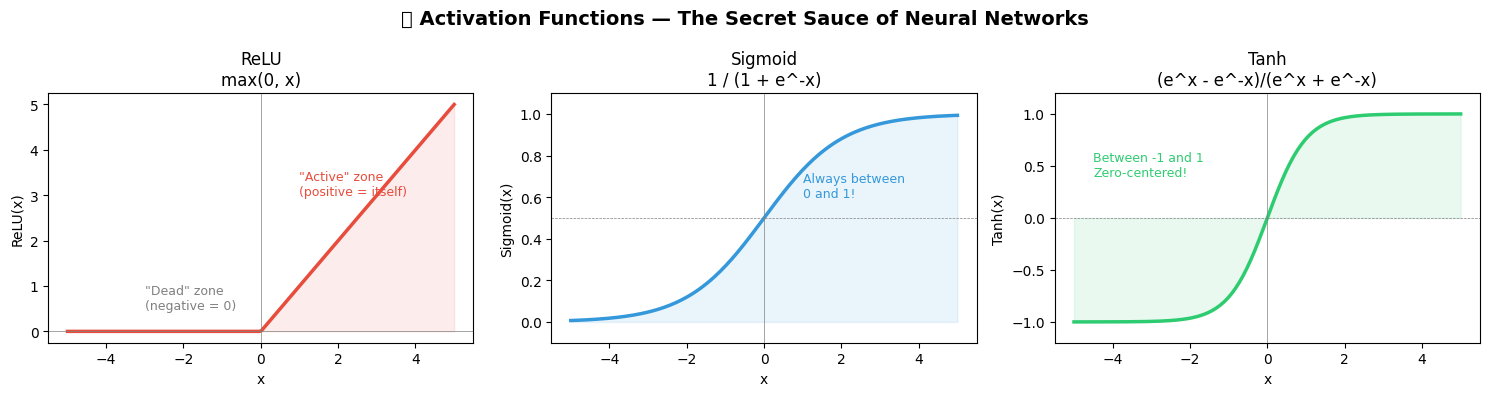

📊 Activation functions plotted above!


In [4]:
# ============================================================
# 🔥 STEP 4: Activation Functions
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ---- ReLU: "if positive, keep it. If negative, kill it." ----
def relu(x):
    return np.maximum(0, x)   # Super simple!

# ---- Sigmoid: squashes ANY number into range (0, 1) ----
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# ---- Softmax: converts raw scores into probabilities ----
def softmax(x):
    exp_x = np.exp(x - np.max(x))  # Stability trick!
    return exp_x / exp_x.sum()

# Let's visualize them!
x = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('🔥 Activation Functions — The Secret Sauce of Neural Networks',
             fontsize=14, fontweight='bold')

# ReLU
axes[0].plot(x, relu(x), color='#e74c3c', linewidth=2.5)
axes[0].set_title('ReLU\nmax(0, x)', fontsize=12)
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].fill_between(x, relu(x), alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('x'); axes[0].set_ylabel('ReLU(x)')
axes[0].annotate('"Dead" zone\n(negative = 0)', xy=(-3, 0.5), color='gray', fontsize=9)
axes[0].annotate('"Active" zone\n(positive = itself)', xy=(1, 3), color='#e74c3c', fontsize=9)

# Sigmoid
axes[1].plot(x, sigmoid(x), color='#3498db', linewidth=2.5)
axes[1].set_title('Sigmoid\n1 / (1 + e^-x)', fontsize=12)
axes[1].axhline(0.5, color='gray', linewidth=0.5, linestyle='--')
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].fill_between(x, sigmoid(x), alpha=0.1, color='#3498db')
axes[1].set_xlabel('x'); axes[1].set_ylabel('Sigmoid(x)')
axes[1].set_ylim(-0.1, 1.1)
axes[1].annotate('Always between\n0 and 1!', xy=(1, 0.6), color='#3498db', fontsize=9)

# Tanh
axes[2].plot(x, np.tanh(x), color='#2ecc71', linewidth=2.5)
axes[2].set_title('Tanh\n(e^x - e^-x)/(e^x + e^-x)', fontsize=12)
axes[2].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[2].axvline(0, color='gray', linewidth=0.5)
axes[2].fill_between(x, np.tanh(x), alpha=0.1, color='#2ecc71')
axes[2].set_xlabel('x'); axes[2].set_ylabel('Tanh(x)')
axes[2].set_ylim(-1.2, 1.2)
axes[2].annotate('Between -1 and 1\nZero-centered!', xy=(-4.5, 0.4), color='#2ecc71', fontsize=9)

plt.tight_layout()
plt.savefig('activation_functions.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Activation functions plotted above!")

---
## Part 4: 🏗️ Building the Neural Network — Object-Oriented Style!

Now we'll build a proper `Layer` class and `NeuralNetwork` class.

This is how **real** neural network libraries work under the hood!

In [5]:
# ============================================================
# 🏗️ STEP 5: A Dense (Fully Connected) Layer Class
# ============================================================

import numpy as np

class DenseLayer:
    """
    A single fully-connected layer.

    'Dense' means every neuron is connected to every input.
    This is the most basic type of layer!
    """

    def __init__(self, n_inputs, n_neurons):
        """
        Initialize the layer with RANDOM weights & ZERO biases.

        Why random weights?
        - If all weights were the same, all neurons would learn the same thing!
        - Random initialization "breaks symmetry" so each neuron learns differently.

        Why *0.01? To keep initial weights small — avoids exploding gradients!
        """
        # Shape: (n_inputs × n_neurons) — one column of weights per neuron
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)

        # Biases start at zero (common practice)
        self.biases  = np.zeros((1, n_neurons))

        print(f"  ✅ Layer created: {n_inputs} inputs → {n_neurons} neurons")
        print(f"     Weights shape: {self.weights.shape}")
        print(f"     Biases shape:  {self.biases.shape}")

    def forward(self, inputs):
        """
        The FORWARD PASS — compute the output of this layer.

        output = inputs @ weights + biases

        @ is matrix multiplication (same as np.dot for 2D arrays)
        """
        self.inputs = inputs  # Save for backpropagation later!
        self.output = np.dot(inputs, self.weights) + self.biases
        return self.output


# ---- Activation Functions as Classes ----

class ReLU:
    """ReLU Activation — clips negatives to zero."""

    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.maximum(0, inputs)  # That's it! One line.
        return self.output


class Sigmoid:
    """Sigmoid Activation — squashes output to (0, 1). Great for binary classification!"""

    def forward(self, inputs):
        self.inputs = inputs
        self.output = 1 / (1 + np.exp(-inputs))
        return self.output


# Test it!
print("🏗️ Creating a simple layer...")
np.random.seed(42)  # For reproducibility
layer = DenseLayer(n_inputs=3, n_neurons=4)

sample_input = np.array([[1.0, 2.0, 3.0]])
output = layer.forward(sample_input)
print(f"\n  Input:  {sample_input}")
print(f"  Output (before activation): {output.round(4)}")

relu = ReLU()
activated_output = relu.forward(output)
print(f"  Output (after ReLU):        {activated_output.round(4)}")
print("\n  Notice: Negative values become 0 after ReLU!")

🏗️ Creating a simple layer...
  ✅ Layer created: 3 inputs → 4 neurons
     Weights shape: (3, 4)
     Biases shape:  (1, 4)

  Input:  [[1. 2. 3.]]
  Output (before activation): [[-0.0138  0.0102  0.0242  0.0166]]
  Output (after ReLU):        [[0.     0.0102 0.0242 0.0166]]

  Notice: Negative values become 0 after ReLU!


In [6]:
# ============================================================
# 🏗️ STEP 6: The Full Neural Network Class
# ============================================================

class NeuralNetwork:
    """
    A complete Neural Network built from scratch!

    Architecture: Input → Dense → ReLU → Dense → ReLU → Dense → Sigmoid
    """

    def __init__(self, layer_sizes):
        """
        layer_sizes = [4, 8, 4, 1] means:
          - Input:    4 features
          - Hidden1:  8 neurons with ReLU
          - Hidden2:  4 neurons with ReLU
          - Output:   1 neuron with Sigmoid
        """
        self.layers = []
        self.activations = []

        print("🏗️ Building Neural Network:")
        print(f"   Architecture: {' → '.join(map(str, layer_sizes))}")
        print()

        for i in range(len(layer_sizes) - 1):
            layer = DenseLayer(layer_sizes[i], layer_sizes[i+1])
            self.layers.append(layer)

            # Last layer: sigmoid (for binary output 0 or 1)
            # Hidden layers: ReLU
            if i == len(layer_sizes) - 2:
                self.activations.append(Sigmoid())
                print(f"     ↳ Activation: Sigmoid")
            else:
                self.activations.append(ReLU())
                print(f"     ↳ Activation: ReLU")
            print()

        print("✅ Network ready!")

    def forward(self, X):
        """
        FORWARD PASS: Data flows from input → output.
        Each layer transforms the data a little.
        Think of it as passing data through a conveyor belt!
        """
        current = X

        for layer, activation in zip(self.layers, self.activations):
            current = layer.forward(current)      # Linear transformation
            current = activation.forward(current)  # Non-linear activation

        return current

    def predict(self, X):
        """Returns binary predictions (0 or 1) by thresholding at 0.5."""
        probabilities = self.forward(X)
        return (probabilities >= 0.5).astype(int)


# Build a network!
np.random.seed(42)
print("=" * 50)
net = NeuralNetwork(layer_sizes=[4, 8, 4, 1])
print("=" * 50)

# Test with a dummy input
dummy_input = np.random.randn(5, 4)  # 5 samples, 4 features each
output = net.forward(dummy_input)

print(f"\n🎯 Forward pass on 5 samples:")
print(f"   Input shape:  {dummy_input.shape}")
print(f"   Output shape: {output.shape}")
print(f"   Output (probabilities):")
for i, prob in enumerate(output):
    print(f"     Sample {i+1}: {prob[0]:.4f}  → Predicted class: {1 if prob[0] >= 0.5 else 0}")

🏗️ Building Neural Network:
   Architecture: 4 → 8 → 4 → 1

  ✅ Layer created: 4 inputs → 8 neurons
     Weights shape: (4, 8)
     Biases shape:  (1, 8)
     ↳ Activation: ReLU

  ✅ Layer created: 8 inputs → 4 neurons
     Weights shape: (8, 4)
     Biases shape:  (1, 4)
     ↳ Activation: ReLU

  ✅ Layer created: 4 inputs → 1 neurons
     Weights shape: (4, 1)
     Biases shape:  (1, 1)
     ↳ Activation: Sigmoid

✅ Network ready!

🎯 Forward pass on 5 samples:
   Input shape:  (5, 4)
   Output shape: (5, 1)
   Output (probabilities):
     Sample 1: 0.5000  → Predicted class: 1
     Sample 2: 0.5000  → Predicted class: 1
     Sample 3: 0.5000  → Predicted class: 1
     Sample 4: 0.5000  → Predicted class: 1
     Sample 5: 0.5000  → Predicted class: 1


---
## Part 5: 🎯 Loss Functions — How Wrong Are We?

The network makes predictions. But how do we know if they're **good** or **bad**?

Enter the **Loss Function** — it measures the **error** between prediction and truth.

| Task | Loss Function | Formula |
|---|---|---|
| Binary Classification | Binary Cross-Entropy | `-[y·log(ŷ) + (1-y)·log(1-ŷ)]` |
| Multi-class | Categorical Cross-Entropy | `-Σ y·log(ŷ)` |
| Regression | Mean Squared Error | `(1/n) Σ (y - ŷ)²` |

**Goal: minimize the loss!** Lower loss = better predictions = smarter network.

> 🎓 Think of it like this: The loss is your **exam score error**. If you score 45% on an exam, your error is 55%. Studying (training) reduces this error over time!

In [7]:
# ============================================================
# 🎯 STEP 7: Loss Functions
# ============================================================

def binary_cross_entropy(y_true, y_pred):
    """
    Binary Cross-Entropy Loss.

    Perfect prediction → loss near 0
    Terrible prediction → loss is high

    The clip() avoids log(0) which is -infinity!
    """
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)  # Safety clip!
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


def mean_squared_error(y_true, y_pred):
    """MSE Loss — great for regression tasks."""
    return np.mean((y_true - y_pred) ** 2)


# Let's see loss in action!
print("🎯 Loss Function Demo")
print("=" * 40)

y_true = np.array([[1], [0], [1], [1], [0]])

scenarios = {
    "Perfect Prediction": np.array([[0.99], [0.01], [0.99], [0.99], [0.01]]),
    "Random Guessing":    np.array([[0.5],  [0.5],  [0.5],  [0.5],  [0.5]]),
    "Terrible Prediction":np.array([[0.01], [0.99], [0.01], [0.01], [0.99]]),
}

for name, y_pred in scenarios.items():
    loss = binary_cross_entropy(y_true, y_pred)
    bar = "█" * int(loss * 20)
    print(f"\n  {name}")
    print(f"  Loss: {loss:.4f}  {bar}")

print("\n💡 Lower loss = better predictions!")
print("   Our goal during training: MINIMIZE the loss!")

🎯 Loss Function Demo

  Perfect Prediction
  Loss: 0.0101  

  Random Guessing
  Loss: 0.6931  █████████████

  Terrible Prediction
  Loss: 4.6052  ████████████████████████████████████████████████████████████████████████████████████████████

💡 Lower loss = better predictions!
   Our goal during training: MINIMIZE the loss!


---
## Part 6: 🔙 Backpropagation — How the Network LEARNS!

This is the magic part! 🪄

**Backpropagation** is how the network figures out which weights to adjust and by how much.

The idea:
1. Make a prediction (forward pass)
2. Calculate the loss (how wrong were we?)
3. **Propagate the error BACKWARDS** through the layers
4. Adjust each weight using **Gradient Descent**

### 📐 Gradient Descent in plain English:

Imagine you're blindfolded on a hilly terrain and you want to reach the lowest valley. You feel the ground with your foot and take small steps **downhill**. That's gradient descent!

```
weight = weight - learning_rate × gradient
```

- `gradient` = slope of the loss (which direction is downhill?)
- `learning_rate` = how big of a step to take (too big → overshoot, too small → too slow)

In [8]:
# ============================================================
# 🔙 STEP 8: Full Backpropagation Implementation
# ============================================================

class DenseLayerWithBackprop:
    """Dense Layer with both forward AND backward passes."""

    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases  = np.zeros((1, n_neurons))

    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.dot(inputs, self.weights) + self.biases
        return self.output

    def backward(self, d_output):
        """
        BACKWARD PASS — compute gradients.

        d_output = gradient flowing in from the NEXT layer

        Using the chain rule from calculus:
        ∂L/∂W = inputs.T @ d_output  ← gradient for weights
        ∂L/∂b = sum(d_output)         ← gradient for biases
        ∂L/∂x = d_output @ W.T        ← gradient to pass backward
        """
        self.d_weights = np.dot(self.inputs.T, d_output)
        self.d_biases  = np.sum(d_output, axis=0, keepdims=True)
        self.d_inputs  = np.dot(d_output, self.weights.T)
        return self.d_inputs

    def update(self, learning_rate):
        """Gradient Descent — adjust weights to reduce loss!"""
        self.weights -= learning_rate * self.d_weights
        self.biases  -= learning_rate * self.d_biases


class ReLUWithBackprop:
    """ReLU with backward pass."""

    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.maximum(0, inputs)
        return self.output

    def backward(self, d_output):
        """
        Gradient of ReLU:
        - If input > 0: gradient passes through unchanged (=1)
        - If input ≤ 0: gradient is killed (=0)  ← dead neurons!
        """
        return d_output * (self.inputs > 0)


class SigmoidWithBackprop:
    """Sigmoid with backward pass."""

    def forward(self, inputs):
        self.output = 1 / (1 + np.exp(-inputs))
        return self.output

    def backward(self, d_output):
        """
        Gradient of sigmoid: s(x) × (1 - s(x))
        """
        return d_output * self.output * (1 - self.output)


print("✅ Backpropagation-ready classes defined!")
print("\n📐 Quick test:")

np.random.seed(42)
layer = DenseLayerWithBackprop(3, 2)
relu  = ReLUWithBackprop()

x = np.array([[1.0, 2.0, 3.0]])
out1 = layer.forward(x)
out2 = relu.forward(out1)

# Fake gradient from next layer
fake_grad = np.array([[1.0, -1.0]])
d1 = relu.backward(fake_grad)
d0 = layer.backward(d1)

print(f"   Input: {x}")
print(f"   Layer output: {out1.round(4)}")
print(f"   After ReLU:   {out2.round(4)}")
print(f"   Grad w.r.t. weights: {layer.d_weights.round(4)}")
print(f"   Grad w.r.t. input:   {d0.round(4)}")

✅ Backpropagation-ready classes defined!

📐 Quick test:
   Input: [[1. 2. 3.]]
   Layer output: [[0.0109 0.0221]]
   After ReLU:   [[0.0109 0.0221]]
   Grad w.r.t. weights: [[ 1. -1.]
 [ 2. -2.]
 [ 3. -3.]]
   Grad w.r.t. input:   [[ 0.0063 -0.0088 -0.    ]]


---
## Part 7: 🚀 Putting It All Together — Train the Network!

Time to train our neural network on a **real problem**!

We'll use the classic **XOR problem** — a simple dataset that NO linear model can solve, but a neural network handles easily.

| x1 | x2 | XOR Output |
|----|----|------------|
| 0  | 0  | 0 |
| 0  | 1  | 1 |
| 1  | 0  | 1 |
| 1  | 1  | 0 |

XOR means: "output 1 if inputs are **different**, 0 if inputs are **same**"

> 🎓 **Why XOR?** It's non-linearly separable — you can't draw a straight line to separate the 1s from the 0s. This is why activation functions + multiple layers are needed!

In [9]:
# ============================================================
# 🚀 STEP 9: Training the Network on XOR Problem!
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ---- XOR Dataset ----
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=float)

y = np.array([[0],
              [1],
              [1],
              [0]], dtype=float)

print("📊 XOR Dataset:")
print("  x1  x2  →  y")
print("  ─────────────")
for i in range(len(X)):
    print(f"   {int(X[i,0])}   {int(X[i,1])}  →  {int(y[i,0])}")


# ---- Build the Network ----
np.random.seed(42)

# 2 inputs → 4 hidden → 1 output
layer1 = DenseLayerWithBackprop(2, 4)
relu1  = ReLUWithBackprop()
layer2 = DenseLayerWithBackprop(4, 1)
sigmoid_out = SigmoidWithBackprop()

learning_rate = 0.5
epochs        = 5000
loss_history  = []

print("\n🚀 Training started...")
print("   (This might take a moment — the network is learning!)")

# ---- Training Loop ----
for epoch in range(epochs):

    # ───── FORWARD PASS ─────
    out1  = layer1.forward(X)
    act1  = relu1.forward(out1)
    out2  = layer2.forward(act1)
    y_hat = sigmoid_out.forward(out2)  # Final predictions!

    # ───── COMPUTE LOSS ─────
    y_hat_clipped = np.clip(y_hat, 1e-7, 1 - 1e-7)
    loss = -np.mean(y * np.log(y_hat_clipped) + (1 - y) * np.log(1 - y_hat_clipped))
    loss_history.append(loss)

    # ───── BACKWARD PASS ─────
    # Gradient of loss w.r.t. sigmoid output
    d_loss = (y_hat - y) / len(X)

    d_sig   = sigmoid_out.backward(d_loss)
    d_l2    = layer2.backward(d_sig)
    d_relu1 = relu1.backward(d_l2)
    d_l1    = layer1.backward(d_relu1)

    # ───── UPDATE WEIGHTS ─────
    layer1.update(learning_rate)
    layer2.update(learning_rate)

    # Print progress
    if epoch % 1000 == 0 or epoch == epochs - 1:
        accuracy = np.mean((y_hat >= 0.5).astype(int) == y) * 100
        print(f"   Epoch {epoch:4d} | Loss: {loss:.4f} | Accuracy: {accuracy:.1f}%")

print("\n✅ Training complete!")

# Final Predictions
print("\n🎯 Final Predictions vs Truth:")
print("   x1  x2  |  Truth  Predicted  Correct?")
print("   ─────────────────────────────────────")
for i in range(len(X)):
    pred = y_hat[i, 0]
    pred_class = 1 if pred >= 0.5 else 0
    correct = "✅" if pred_class == int(y[i, 0]) else "❌"
    print(f"    {int(X[i,0])}   {int(X[i,1])}  |    {int(y[i,0])}       {pred:.3f}     {correct}")

📊 XOR Dataset:
  x1  x2  →  y
  ─────────────
   0   0  →  0
   0   1  →  1
   1   0  →  1
   1   1  →  0

🚀 Training started...
   (This might take a moment — the network is learning!)
   Epoch    0 | Loss: 0.6931 | Accuracy: 25.0%
   Epoch 1000 | Loss: 0.4956 | Accuracy: 75.0%
   Epoch 2000 | Loss: 0.4845 | Accuracy: 75.0%
   Epoch 3000 | Loss: 0.4827 | Accuracy: 75.0%
   Epoch 4000 | Loss: 0.4817 | Accuracy: 75.0%
   Epoch 4999 | Loss: 0.4809 | Accuracy: 75.0%

✅ Training complete!

🎯 Final Predictions vs Truth:
   x1  x2  |  Truth  Predicted  Correct?
   ─────────────────────────────────────
    0   0  |    0       0.666     ❌
    0   1  |    1       0.666     ✅
    1   0  |    1       0.666     ✅
    1   1  |    0       0.014     ✅


/tmp/ipykernel_159/758101482.py:61: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_159/758101482.py:61: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_159/758101482.py:61: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_159/758101482.py:62: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_159/758101482.py:62: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_159/758101482.py:62: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-pack

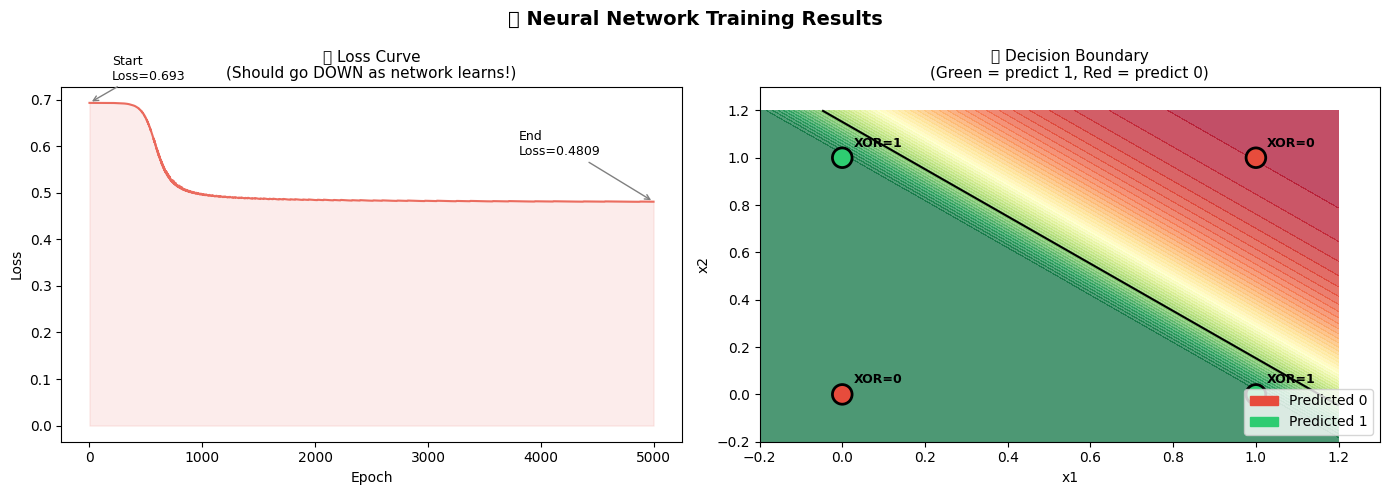

🗺️ The non-linear decision boundary is the magic of neural networks!
   No straight line could have solved XOR — but our network did it!


In [10]:
# ============================================================
# 📈 STEP 10: Visualizing the Training!
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🧠 Neural Network Training Results', fontsize=14, fontweight='bold')

# ---- Plot 1: Loss Curve ----
ax = axes[0]
ax.plot(loss_history, color='#e74c3c', linewidth=1.5, alpha=0.8)
ax.set_title('📉 Loss Curve\n(Should go DOWN as network learns!)', fontsize=11)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.fill_between(range(len(loss_history)), loss_history, alpha=0.1, color='#e74c3c')

# Mark start and end
ax.annotate(f'Start\nLoss={loss_history[0]:.3f}',
            xy=(0, loss_history[0]), xytext=(200, loss_history[0]+0.05),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)
ax.annotate(f'End\nLoss={loss_history[-1]:.4f}',
            xy=(len(loss_history)-1, loss_history[-1]),
            xytext=(len(loss_history)-1200, loss_history[-1]+0.1),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)

# ---- Plot 2: Decision Boundary ----
ax2 = axes[1]
xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, 200), np.linspace(-0.2, 1.2, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Run grid through our trained network
out_g  = layer1.forward(grid)
act_g  = relu1.forward(out_g)
out_g2 = layer2.forward(act_g)
probs  = sigmoid_out.forward(out_g2).reshape(xx.shape)

ax2.contourf(xx, yy, probs, levels=50, cmap='RdYlGn', alpha=0.7)
ax2.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=1.5)

# Plot actual data points
colors = ['#e74c3c' if yi == 0 else '#2ecc71' for yi in y.ravel()]
ax2.scatter(X[:, 0], X[:, 1], c=colors, s=200, zorder=5, edgecolors='black', linewidths=2)

# Label each point
for i, (xi, yi) in enumerate(zip(X, y.ravel())):
    ax2.annotate(f'XOR={int(yi)}', (xi[0], xi[1]),
                 textcoords='offset points', xytext=(8, 8), fontsize=9, fontweight='bold')

ax2.set_title('🗺️ Decision Boundary\n(Green = predict 1, Red = predict 0)', fontsize=11)
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_xlim(-0.2, 1.3)
ax2.set_ylim(-0.2, 1.3)

red_patch = mpatches.Patch(color='#e74c3c', label='Predicted 0')
green_patch = mpatches.Patch(color='#2ecc71', label='Predicted 1')
ax2.legend(handles=[red_patch, green_patch], loc='lower right')

plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("🗺️ The non-linear decision boundary is the magic of neural networks!")
print("   No straight line could have solved XOR — but our network did it!")

---
## Part 8: 🎓 Real Dataset — Breast Cancer Classification!

Let's apply our network to a **real-world medical dataset**: predicting whether a tumor is malignant or benign.

We'll use **sklearn's breast cancer dataset** (just for the data — our network code is still pure scratch!).

In [11]:
# ============================================================
# 🎓 STEP 11: Real Dataset — Breast Cancer Classification
# ============================================================

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
data = load_breast_cancer()
X_data = data.data
y_data = data.target.reshape(-1, 1).astype(float)

print("📊 Breast Cancer Dataset:")
print(f"   Samples:  {X_data.shape[0]}")
print(f"   Features: {X_data.shape[1]}")
print(f"   Classes:  Malignant (0) = {(y_data==0).sum()}, Benign (1) = {(y_data==1).sum()}")

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42
)

# IMPORTANT: Normalize features! Neural networks work better with scaled input.
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\n   Train: {X_train.shape[0]} samples")
print(f"   Test:  {X_test.shape[0]} samples")
print("\n✅ Data ready!")

📊 Breast Cancer Dataset:
   Samples:  569
   Features: 30
   Classes:  Malignant (0) = 212, Benign (1) = 357

   Train: 455 samples
   Test:  114 samples

✅ Data ready!


In [12]:
# ============================================================
# 🚀 STEP 12: Train on Real Data!
# ============================================================

np.random.seed(42)

# Network: 30 inputs → 16 hidden → 8 hidden → 1 output
l1  = DenseLayerWithBackprop(30, 16)
r1  = ReLUWithBackprop()
l2  = DenseLayerWithBackprop(16, 8)
r2  = ReLUWithBackprop()
l3  = DenseLayerWithBackprop(8, 1)
sig = SigmoidWithBackprop()

lr            = 0.05
epochs        = 1000
train_losses  = []
test_losses   = []
train_accs    = []
test_accs     = []

def forward_all(X):
    o1 = r1.forward(l1.forward(X))
    o2 = r2.forward(l2.forward(o1))
    return sig.forward(l3.forward(o2))

def bce_loss(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-7, 1-1e-7)
    return -np.mean(y_true * np.log(y_pred) + (1-y_true) * np.log(1-y_pred))

print("🚀 Training on Breast Cancer Dataset...")
print("─" * 55)
print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Test Loss':>10}  {'Test Acc':>8}")
print("─" * 55)

for epoch in range(epochs):
    # Forward
    y_hat_train = forward_all(X_train)
    train_loss  = bce_loss(y_train, y_hat_train)
    train_acc   = np.mean((y_hat_train >= 0.5).astype(int) == y_train)

    # Backward
    d = (y_hat_train - y_train) / len(X_train)
    d = sig.backward(d)
    d = l3.backward(d)
    d = r2.backward(d)
    d = l2.backward(d)
    d = r1.backward(d)
    l1.backward(d)

    # Update
    for layer in [l1, l2, l3]:
        layer.update(lr)

    # Evaluate on test set (no gradient needed)
    y_hat_test = forward_all(X_test)
    test_loss  = bce_loss(y_test, y_hat_test)
    test_acc   = np.mean((y_hat_test >= 0.5).astype(int) == y_test)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if epoch % 200 == 0 or epoch == epochs-1:
        print(f"{epoch:>6}  {train_loss:>10.4f}  {test_loss:>10.4f}  {test_acc*100:>7.1f}%")

print("─" * 55)
print(f"\n🎯 Final Test Accuracy: {test_accs[-1]*100:.2f}%")
print(f"   Not bad for a network built from SCRATCH! 🎉")

🚀 Training on Breast Cancer Dataset...
───────────────────────────────────────────────────────
 Epoch  Train Loss   Test Loss  Test Acc
───────────────────────────────────────────────────────
     0      0.6931      0.6929     62.3%
   200      0.6696      0.6709     62.3%
   400      0.6627      0.6648     62.3%
   600      0.6607      0.6632     62.3%
   800      0.6600      0.6627     62.3%
   999      0.6598      0.6627     62.3%
───────────────────────────────────────────────────────

🎯 Final Test Accuracy: 62.28%
   Not bad for a network built from SCRATCH! 🎉


/tmp/ipykernel_159/360080800.py:70: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_159/360080800.py:70: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_159/360080800.py:70: UserWarning: Glyph 128450 (\N{CARD INDEX DIVIDERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_159/360080800.py:70: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_159/360080800.py:70: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_159/360080800.py:71: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('cancer_results.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_159/360080800.py:71: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) 

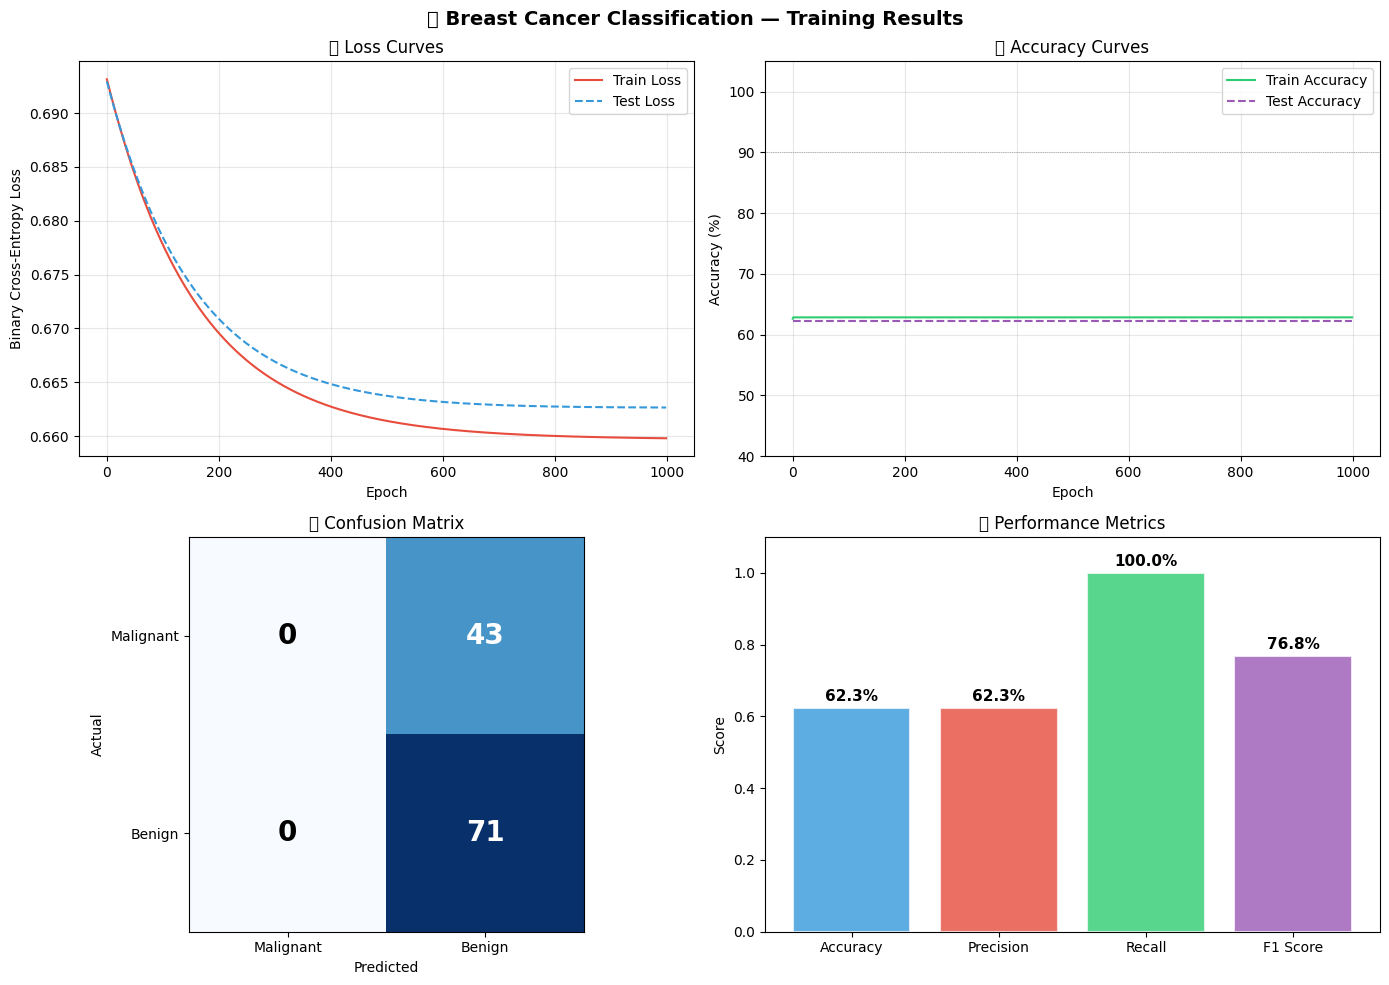


📊 Final Metrics:
   Accuracy:  62.28%
   Precision: 62.28%
   Recall:    100.00%
   F1 Score:  76.76%


In [13]:
# ============================================================
# 📊 STEP 13: Final Results Visualization
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🎓 Breast Cancer Classification — Training Results',
             fontsize=14, fontweight='bold')

# Loss curve
axes[0,0].plot(train_losses, label='Train Loss', color='#e74c3c', linewidth=1.5)
axes[0,0].plot(test_losses,  label='Test Loss',  color='#3498db', linewidth=1.5, linestyle='--')
axes[0,0].set_title('📉 Loss Curves')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Binary Cross-Entropy Loss')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Accuracy curve
axes[0,1].plot([a*100 for a in train_accs], label='Train Accuracy', color='#2ecc71', linewidth=1.5)
axes[0,1].plot([a*100 for a in test_accs],  label='Test Accuracy',  color='#9b59b6', linewidth=1.5, linestyle='--')
axes[0,1].set_title('📈 Accuracy Curves')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy (%)')
axes[0,1].set_ylim(40, 105)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)
axes[0,1].axhline(90, color='gray', linewidth=0.5, linestyle=':')

# Confusion Matrix
y_pred_final = (forward_all(X_test) >= 0.5).astype(int).ravel()
y_true_final = y_test.ravel().astype(int)

TP = np.sum((y_pred_final == 1) & (y_true_final == 1))
TN = np.sum((y_pred_final == 0) & (y_true_final == 0))
FP = np.sum((y_pred_final == 1) & (y_true_final == 0))
FN = np.sum((y_pred_final == 0) & (y_true_final == 1))

cm = np.array([[TN, FP], [FN, TP]])
im = axes[1,0].imshow(cm, cmap='Blues')
axes[1,0].set_title('🗂️ Confusion Matrix')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')
axes[1,0].set_xticks([0,1]); axes[1,0].set_xticklabels(['Malignant', 'Benign'])
axes[1,0].set_yticks([0,1]); axes[1,0].set_yticklabels(['Malignant', 'Benign'])
for i in range(2):
    for j in range(2):
        axes[1,0].text(j, i, cm[i,j], ha='center', va='center',
                       fontsize=20, fontweight='bold',
                       color='white' if cm[i,j] > cm.max()/2 else 'black')

# Summary stats
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
accuracy  = (TP + TN) / (TP + TN + FP + FN)

stats = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]
colors_bar = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

bars = axes[1,1].bar(stats, values, color=colors_bar, alpha=0.8, edgecolor='white', linewidth=1.5)
axes[1,1].set_title('📊 Performance Metrics')
axes[1,1].set_ylim(0, 1.1)
axes[1,1].set_ylabel('Score')

for bar, val in zip(bars, values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                   f'{val*100:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('cancer_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Final Metrics:")
print(f"   Accuracy:  {accuracy*100:.2f}%")
print(f"   Precision: {precision*100:.2f}%")
print(f"   Recall:    {recall*100:.2f}%")
print(f"   F1 Score:  {f1*100:.2f}%")

---
## 🏆 Congratulations! You just built a Neural Network from SCRATCH!

Let's recap everything you've learned:

| Concept | What It Does | One-Liner |
|---------|-------------|-----------|
| **Neuron** | Weighted sum + bias | `output = Σ(x·w) + b` |
| **Layer** | Multiple neurons in parallel | `output = np.dot(W, x) + b` |
| **Activation** | Adds non-linearity | `ReLU: max(0, x)` |
| **Forward Pass** | Data flows input → output | Prediction phase |
| **Loss Function** | Measures how wrong we are | Lower = better |
| **Backpropagation** | Computes gradients via chain rule | Blame game! |
| **Gradient Descent** | Adjusts weights to reduce loss | `w = w - lr × ∇w` |
| **Training Loop** | Repeat forward + backward until convergence | The learning cycle |

### 🚀 What's Next?

Now that you understand the fundamentals, explore these advanced topics:

1. **CNNs** (Convolutional Neural Networks) — for images 🖼️
2. **RNNs / LSTMs / Transformers** — for sequences and text 📝
3. **PyTorch / TensorFlow** — industrial-strength frameworks that use exactly what you just built, but optimized on GPUs ⚡
4. **Dropout & Batch Normalization** — making networks more robust 🛡️
5. **Adam Optimizer** — smarter gradient descent 🧠

> 💡 **Pro Tip:** Everything in PyTorch/TensorFlow is just a cleaned-up, GPU-accelerated version of what you coded today. You now understand what those libraries are doing under the hood!

---
*Built from scratch — no shortcuts, no magic, just math and code! 🧠⚡*

In [ ]:
# ============================================================
# 🎉 BONUS: Quick Cheat Sheet — Everything in One Place!
# ============================================================

print("""
╔══════════════════════════════════════════════════════════╗
║       🧠 NEURAL NETWORK FROM SCRATCH — CHEAT SHEET      ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  SINGLE NEURON:                                          ║
║    output = x1*w1 + x2*w2 + x3*w3 + bias                ║
║                                                          ║
║  LAYER (vectorized):                                     ║
║    output = np.dot(inputs, weights) + biases             ║
║                                                          ║
║  RELU:                                                   ║
║    f(x) = max(0, x)                                      ║
║                                                          ║
║  SIGMOID:                                                ║
║    f(x) = 1 / (1 + exp(-x))                              ║
║                                                          ║
║  BINARY CROSS-ENTROPY LOSS:                              ║
║    L = -mean(y*log(ŷ) + (1-y)*log(1-ŷ))                 ║
║                                                          ║
║  GRADIENT DESCENT:                                       ║
║    weights -= learning_rate * d_weights                  ║
║                                                          ║
║  TRAINING LOOP:                                          ║
║    for epoch in range(N):                                ║
║        y_hat  = forward(X)        # Predict              ║
║        loss   = compute_loss(y, y_hat)  # Measure error  ║
║        grads  = backward(loss)    # Blame assignment     ║
║        update_weights(grads, lr)  # Learn!               ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝

  🎉 You built this entire system from scratch! Amazing work!
""")